In [1]:
# Revenue optimization notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

In [2]:
# Load processed data
daily = pd.read_csv("../data/processed/daily_aggregated.csv")

daily = daily[(daily["daily_demand"] > 0) & (daily["avg_price"] > 0)]

# Use corrected de-trended elasticity
elasticity = -0.02

# Baseline values
base_demand = daily["daily_demand"].mean()
reference_price = daily["avg_price"].mean()

# Business constraints
capacity = 120
price_floor = 50
price_ceiling = 500

print("Elasticity Used:", elasticity)

Elasticity Used: -0.02


In [3]:
def demand_function(price):
    return base_demand * (price / reference_price) ** elasticity

In [4]:
def revenue_function(price):
    demand = demand_function(price[0])
    return -(price[0] * demand)

In [5]:
def capacity_constraint(price):
    return capacity - demand_function(price[0])

In [6]:
constraints = [{"type": "ineq", "fun": capacity_constraint}]
bounds = [(price_floor, price_ceiling)]

result = minimize(
    revenue_function,
    x0=[reference_price],
    bounds=bounds,
    constraints=constraints
)

optimal_price = result.x[0]
optimal_demand = min(demand_function(optimal_price), capacity)
optimal_revenue = optimal_price * optimal_demand

print("Constrained Optimal Price:", round(optimal_price, 2))
print("Expected Demand:", round(optimal_demand, 2))
print("Expected Revenue:", round(optimal_revenue, 2))

Constrained Optimal Price: 500.0
Expected Demand: 88.71
Expected Revenue: 44353.29


In [10]:
constraints = [{"type": "ineq", "fun": capacity_constraint}]
bounds = [(price_floor, price_ceiling)]

result = minimize(
    revenue_function,
    x0=[reference_price],
    bounds=bounds,
    constraints=constraints
)

optimal_price = result.x[0]
optimal_demand = min(demand_function(optimal_price), capacity)
optimal_revenue = optimal_price * optimal_demand

print("Constrained Optimal Price:", round(optimal_price, 2))
print("Expected Demand:", round(optimal_demand, 2))
print("Expected Revenue:", round(optimal_revenue, 2))

Constrained Optimal Price: 190.96
Expected Demand: 120
Expected Revenue: 22914.81


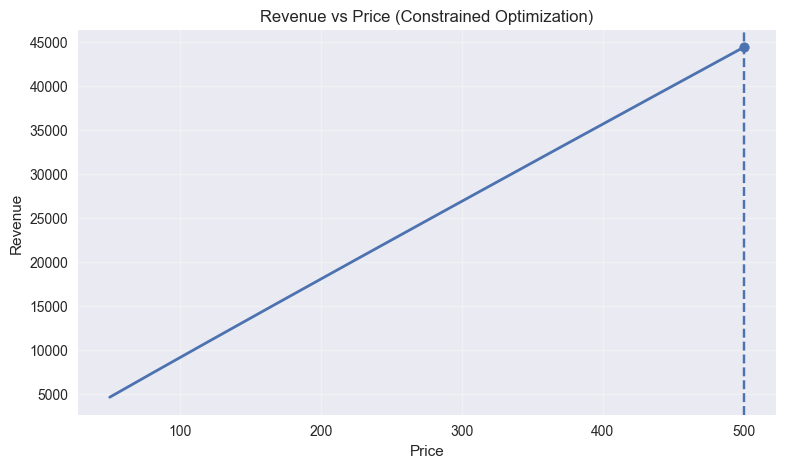

In [7]:
price_range = np.linspace(price_floor, price_ceiling, 300)
revenues = []
demands = []

for p in price_range:
    d = demand_function(p)
    revenues.append(p * d)
    demands.append(d)

revenues = np.array(revenues)
demands = np.array(demands)

plt.figure(figsize=(9,5))
plt.plot(price_range, revenues, linewidth=2)
plt.axvline(optimal_price, linestyle="--")
plt.scatter(optimal_price, optimal_revenue)

plt.title("Revenue vs Price (Constrained Optimization)")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.show()

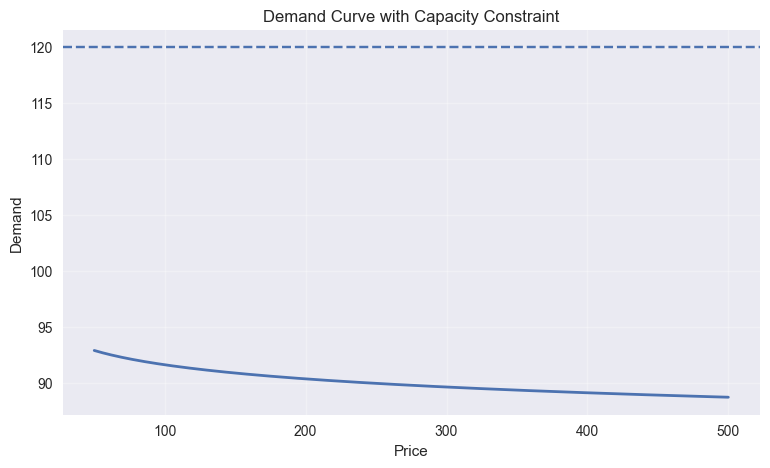

In [8]:
plt.figure(figsize=(9,5))
plt.plot(price_range, demands, linewidth=2)
plt.axhline(capacity, linestyle="--")

plt.title("Demand Curve with Capacity Constraint")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.grid(alpha=0.3)
plt.show()

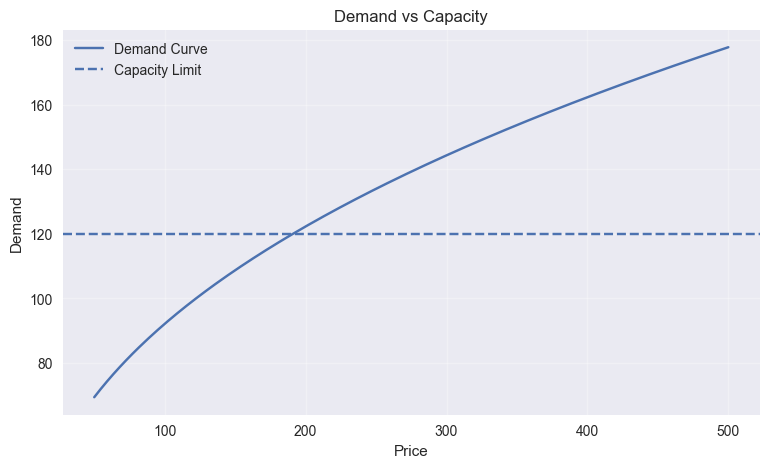

In [14]:
plt.figure(figsize=(9,5))
plt.plot(price_range, demands, label="Demand Curve")
plt.axhline(capacity, linestyle="--", label="Capacity Limit")

plt.title("Demand vs Capacity")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

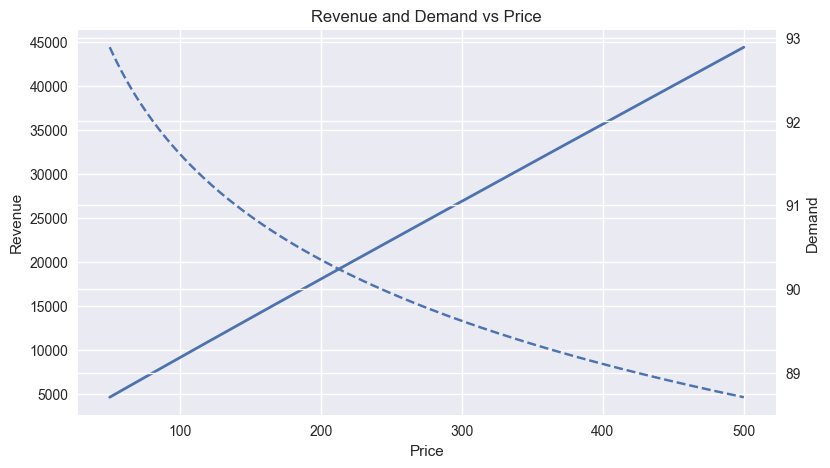

In [9]:
fig, ax1 = plt.subplots(figsize=(9,5))

ax1.plot(price_range, revenues, linewidth=2)
ax1.set_xlabel("Price")
ax1.set_ylabel("Revenue")

ax2 = ax1.twinx()
ax2.plot(price_range, demands, linestyle="--")
ax2.set_ylabel("Demand")

plt.title("Revenue and Demand vs Price")
plt.show()